# **Interactive Customer Churn Analytics Dashboard**

## **Objective**
The objective of this project is to analyze customer churn using the Telecom Customer Churn dataset. The project includes data preprocessing, feature engineering, KPI analysis, exploratory data analysis using Seaborn, and interactive dashboard creation using Plotly. The insights generated from the dashboard help identify factors affecting customer churn and support better business decisions.


# **Phase 1: Business Problem Understanding.**
# **Business Problem**:

telecome company ke bahut sare customer company chod rahe hai (churn kar rahe hai).




# **Business Goal:**
churn karne vale customer ko identify krna.

churn ke reasons samajhna .

comapny ko retention stratagy dena.



# **Business Questions:**

Kitne customers churn kar rahe hain?

Kaunse customers zyada churn karte hain?

Kya contract type churn ko affect karta hai?

Kya monthly charges churn ko affect karte hain?

Kya internet service churn ko affect karti hai?

# **Phase 2 :Data Understanding**



**1) Import Libraries**

In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px

**2) Load Dataset**

In [83]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/kaggle data/archive (1).zip")

**3) First Look At Data**

purpose:

columns samajhna

data structures dekhna

In [84]:
df.head()  # show first 5 rows data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



**4) Dataset Shape**

purpose:

rows aur columns ki count check krna.

In [85]:
df.shape  # count rows and columns

(7043, 21)

**5) Column Information**:

purpose:

datatypes dekhna.

missing values identify krna.

memory usage check krna.


In [86]:
df.info()  # summary of dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Observation :**

1.dataset conatains 7043 customer records and 21 columns.

2.no missing values are observed based on df.info().

3.most variable are categorical(object datatype).

4.monthly charges is numerical feature(float64).

5.tenure and seniorcitizen are integer features.

6.totalcharges is stored as object instead of numeric and required datatype conversion during data cleaning.


**6) Statistical Summary**

purpose:

mean

median

min

max

standard deviation

In [87]:
df.describe()   # give a statistical summary.

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Observation:**

1.the dataset contains 7043 customer records with no missing values in numerical column.

2.the average customer tenure is 32.37 months.

3.the average monthly charges is 64.76 .

4.the maximum tenure is 72 months, indicates long-term customers.

5.Around 16% of customer are seniorcitizen.

# **Phase 3: Data Cleaning.**

**1)Missing Values**:

In [88]:
df.isnull().sum()  # counts missing values.

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**Missing Values Analysis :**

the dataset was checked using df.isnull().sum().

no missing(null) values were found in any of the 21 columns,indicating that the dataset is complete.

however,the total charges columns requires further inspection because it is stored as an object datatype instead of numeric datatype.

**2)Convert DataTypes**:

In [89]:
# convert datatypes of totalcharges.
df["TotalCharges"]=pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.info()  #now check that datatype of totalcharges is converted.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Observation**:

totalcharges datatype is converted into numerical(float64) datatyppe.

**3)Check Missing Values**

In [90]:
# check that how many  missing values are create.
df["TotalCharges"].isnull().sum()

np.int64(11)

**Observation:**

The TotalCharges column was originally stored as an object datatype due to the presence of blank values. It was converted to a numeric datatype using pd.to_numeric() with errors='coerce', which replaced invalid values with NaN for further processing.

**4) Handle Missing Values**

In [91]:
df.dropna(inplace=True)  # remove missing rows values.

In [92]:
df.shape  # check the missing rows values are deleted or not.

(7032, 21)

**5)Remove Duplicates Rows**

In [93]:
df.drop_duplicates(    # remove duplicates.
    inplace=True
)

In [94]:
df.duplicated().sum()  # check duplicate rows.

np.int64(0)

In [95]:
df.shape

(7032, 21)

**6) Convert Target Variable**

In [96]:
# convert catogerical values into numerical values.
df["Churn"] = df["Churn"].map(
    {
        "Yes":1,
        "No":0
    }
)

df["Churn"].head()  # check values are converted or not.

,Churn
0,0
1,0
2,1
3,0
4,1


**Observation:**

The Churn column was converted from categorical values (Yes and No) to numerical values (1 and 0) using the map() function.

This transformation makes the data suitable for numerical analysis, visualization, and machine learning models.

# **phase 4: KPI Analysis**

**KPI-1 : Total Customer**



In [97]:
total_Customers = len(df)
print(total_Customers)

7032


**KPI-2 :Churn Customer**

In [98]:
churn_customers = df["Churn"].sum()
print(churn_customers)

1869


**KPI-3 :Churn Rate**

In [99]:
churn_rate = (churn_customers / total_Customers) * 100
print(churn_rate)

26.578498293515356


**KPI-4: Average Monthly Charges**

In [100]:
avg_monthly_charges =df["MonthlyCharges"].mean()
print(avg_monthly_charges)

64.79820819112628


**Observation:**

The KPI analysis provides a quick overview of the telecom company's customer base. The dataset contains 7,032 customers, with 1,869 churned customers and an average monthly charge of $64.76. The 26.58% churn rate highlights the importance of improving customer retention and reducing customer loss.

# **Phase 5 : Feature Engineering**

In [101]:
# for a create new column
import pandas as pd
bins = [0,12,24,48,72]

labels = [
    "0-1 Year",
    "1-2 Years",
    "2-4 Years",
    "4-6 Years"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels
)
df["TenureGroup"].head()   # print tenureGroup column.



,TenureGroup
0,0-1 Year
1,2-4 Years
2,0-1 Year
3,2-4 Years
4,0-1 Year


**Observation**:

A new feature named TenureGroup was created by grouping customers based on their tenure. This makes it easier to analyze customer behavior across different service durations and compare churn trends between short-term and long-term customers.

# **Phase 6: Exploratory Data Analysis**

**1. Churn Distribution (Countplot)**

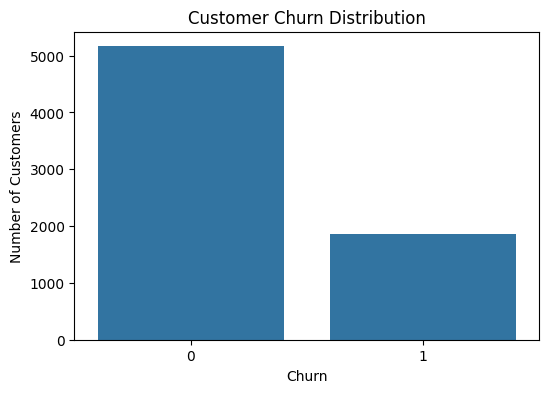

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

**Observation:**

The number of non-churn customers is higher than churn customers.

Most customers have continued using the telecom services.

**Business Insight:**

The company has retained the majority of its customers.

However, churned customers still represent a significant portion, indicating the need for customer retention strategies.

**2. Gender vs Churn**

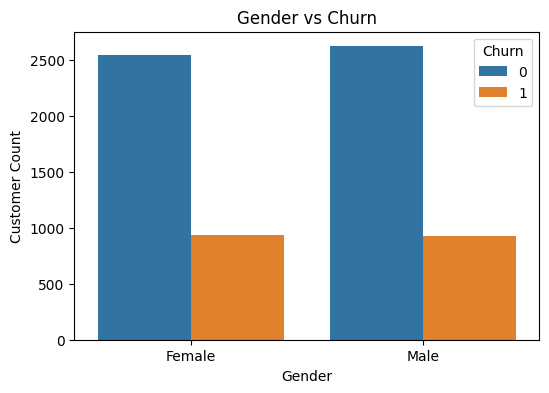

In [103]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Customer Count")
plt.show()

**Observation:**

Male and female customers show a similar churn pattern
.
No major difference is observed between genders.

**Business Insight:**

Gender does not appear to be a strong factor influencing customer churn.

The company should focus on other customer attributes instead.

**3. Contract Type vs Churn**

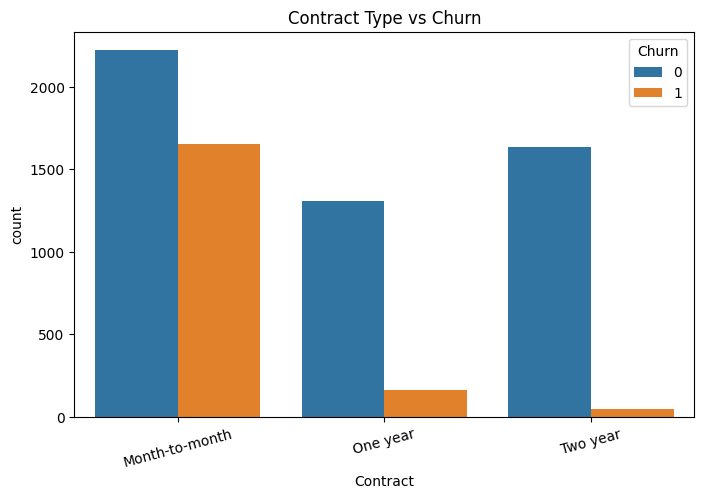

In [104]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

**Observation:**

Month-to-month contract customers have the highest churn.

One-year and two-year contract customers churn less.

**Business Insight:**

Long-term contracts improve customer retention.

The company should encourage customers to switch to longer-duration contract

**4. Internet Service vs Churn**

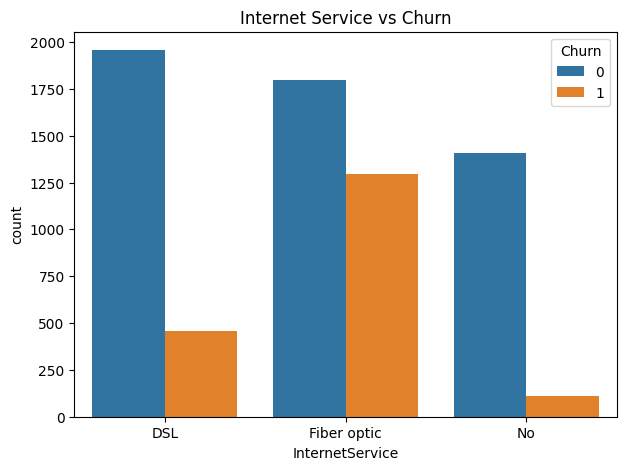

In [105]:
plt.figure(figsize=(7,5))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet Service vs Churn")
plt.show()

**Observation:**

Fiber optic customers show a higher churn count.

DSL customers have relatively lower churn.

**Business Insight:**

The company should investigate why Fiber Optic users leave more frequently.

Improving service quality may help reduce churn.

**5. Payment Method vs Churn**

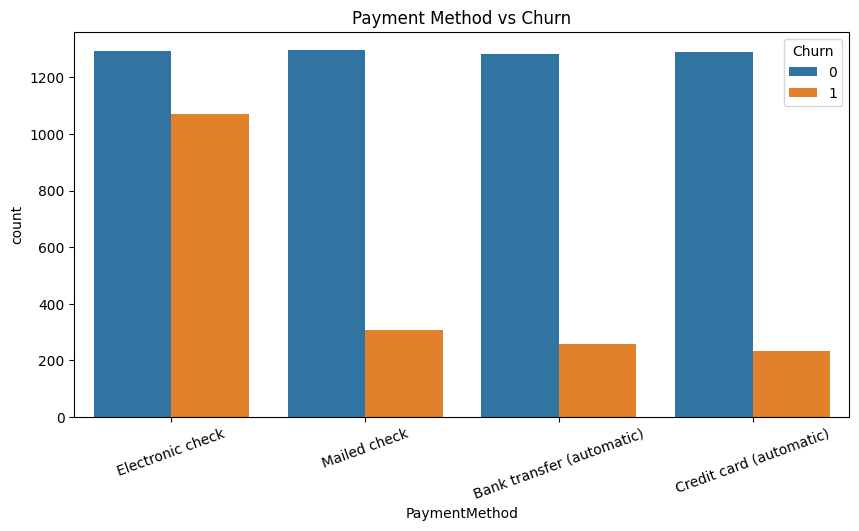

In [106]:
plt.figure(figsize=(10,5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=20)
plt.title("Payment Method vs Churn")
plt.show()

**Observation:**

Customers using Electronic Check have a higher churn count.

Automatic payment methods show lower churn.

**Business Insight:**

Encouraging automatic payment methods may improve customer retention.

Electronic Check users may require special retention campaigns.

**6. Monthly Charges Distribution**

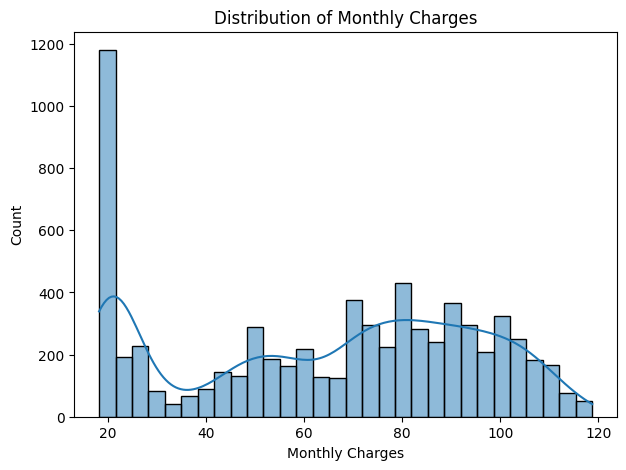

In [107]:
plt.figure(figsize=(7,5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.show()

**Observation:**

Monthly charges vary across customers.

Most customers are concentrated in the medium charge range.

**Business Insight:**

Pricing strategies should focus on customers with higher monthly charges, as they may be more likely to churn.

**7. Tenure Distribution**

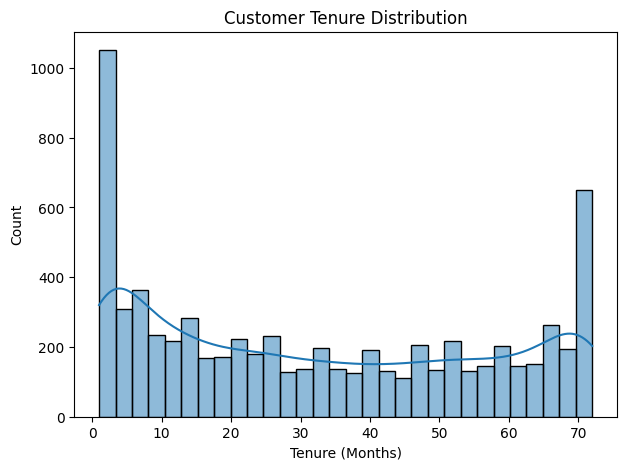

In [108]:
plt.figure(figsize=(7,5))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.show()

**Observation:**

Many customers have a shorter tenure.

Fewer customers stay with the company for a very long period.

**Business Insight:**

The initial months are critical for customer retention.

Providing better onboarding and support for new customers may reduce churn.

**8. Correlation Heatmap**

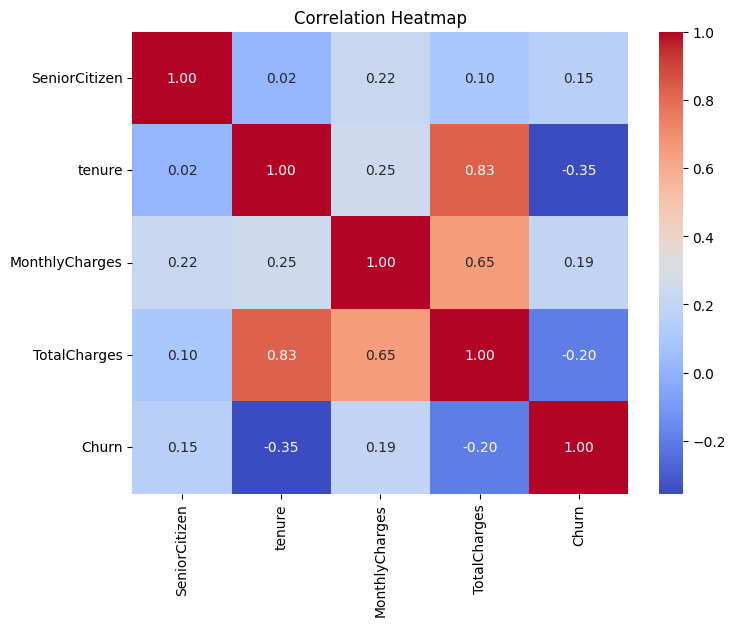

In [109]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

**Observation:**

Numerical features show weak to moderate correlations.

Monthly Charges and Total Charges have a positive correlation.

**Business Insight:**

Highly correlated variables can provide valuable business insights.

Understanding these relationships helps in predicting customer churn and making informed decisions.

# **EDA Conclusion (Report)**





The Exploratory Data Analysis indicates that customer churn is strongly associated with contract type, internet service, payment method, tenure, and monthly charges.

 Customers with month-to-month contracts, Fiber Optic service, Electronic Check payments, shorter tenure, and higher monthly charges are more likely to churn. These insights can help the company improve customer retention and reduce churn.

# **Phase 7: Interactive Dashboard (Plotly)**

**Import Plotly:**

In [110]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

**Create KPI Cards:**

In [111]:
total_customers = len(df)
churn_customers = df["Churn"].sum()
avg_monthly = round(df["MonthlyCharges"].mean(), 2)
churn_rate = round((churn_customers / total_customers) * 100, 2)

print("Total Customers:", total_customers)
print("Churn Customers:", churn_customers)
print("Average Monthly Charges:", avg_monthly)
print("Churn Rate:", churn_rate, "%")

Total Customers: 7032
Churn Customers: 1869
Average Monthly Charges: 64.8
Churn Rate: 26.58 %


**Churn Distribution:**

In [112]:
fig = px.pie(
    df,
    names="Churn",
    title="Customer Churn Distribution",
    hole=0.4
)

fig.show()

**Business Insight:**

Most customers are retained, but around one-fourth have churned.

**Gender vs Churn:**

In [113]:
fig = px.histogram(
    df,
    x="gender",
    color="Churn",
    barmode="group",
    title="Gender vs Churn"
)

fig.show()

**Business Insight:**

Churn behaviour is similar for both genders.

**Contract vs Churn:**

In [114]:
fig = px.histogram(
    df,
    x="Contract",
    color="Churn",
    barmode="group",
    title="Contract Type vs Churn"
)

fig.show()

**Business Insight:**

Month-to-month customers churn much more frequently than customers with long-term contracts

**Internet Service vs Churn:**

In [115]:
fig = px.histogram(
    df,
    x="InternetService",
    color="Churn",
    barmode="group",
    title="Internet Service vs Churn"
)

fig.show()

**Business Insight:**

Fiber Optic users have the highest churn rate.

**Payment Method vs Churn:**

In [116]:
fig = px.histogram(
    df,
    x="PaymentMethod",
    color="Churn",
    barmode="group",
    title="Payment Method vs Churn"
)

fig.show()

**Business Insight:**

Customers using Electronic Check are more likely to churn.

**Monthly Charges Histogram:**

In [117]:
fig = px.histogram(
    df,
    x="MonthlyCharges",
    nbins=30,
    title="Monthly Charges Distribution"
)

fig.show()

**Business Insight:**

Most customers fall into the medium monthly charge range.

**Tenure Group Chart:**

In [118]:
fig = px.histogram(
    df,
    x="TenureGroup",
    color="Churn",
    barmode="group",
    title="Tenure Group vs Churn"
)

fig.show()

**Business Insight:**

Customers with shorter tenure are more likely to leave the company.

# **Business Recommendations**

1)Encourage customers to choose One-Year or Two-Year contracts through discounts and loyalty benefits.

2)Improve the quality and customer support of Fiber Optic internet services to reduce churn.

3)Provide special offers to customers with high monthly charges to improve retention.

4)Encourage customers to use automatic payment methods instead of Electronic Check.

5)Launch retention campaigns for new customers (low tenure) during their first year.

These recommendations can help reduce customer churn and improve long-term customer retention.

# **Conclusion**

This project analyzed customer churn using Python, Pandas, Seaborn, and Plotly. Data cleaning, feature engineering, KPI analysis, and interactive visualizations helped identify important churn patterns. The analysis showed that contract type, tenure, monthly charges, internet service, and payment method significantly influence customer churn. The dashboard provides valuable business insights that can help the company improve customer retention and reduce customer loss.


### **Future Scope:**
This dashboard can be integrated with real-time customer data and machine learning models to predict customer churn proactively.

# **Tools & Technologies Used**
Python

Google Colab

Pandas

NumPy

Seaborn

Matplotlib

Plotly

# **Thank You**

This project was developed using Python, Pandas, Seaborn, Matplotlib, and Plotly to analyze customer churn and generate business insights.